# FigOpticalDepth — Lyman- and Balmer-continuum optical depth vs radius

Cumulative **effective** optical depth (solid) and **absorption-only** (dashed) at the Lyman (912 A),
Balmer (3646 A) and Paschen edges for the marginally-unbound `dilute_redd` grid
($\dot M = 2.5,\,5,\,10,\,20\,M_\odot$/yr), integrated outward from the base over converged cells only:
$\tau_{\rm abs}=\int n_i\sigma_i\,dr'$, $\tau_{\rm es}=\int n_e\sigma_T\,dr'$,
$\tau_{\rm eff}=\sqrt{\tau_{\rm abs}(\tau_{\rm abs}+\tau_{\rm es})}$, with
$n_1=\mathtt{ion\_den}\times\mathtt{lev1}$ (LyC), $n_2$ (BaC), $n_3$ (PaC). Thin vertical lines mark the
spectral break radii ($J_\nu$ red/blue jump $> 5$ across each edge), goldenrod marks the
electron-scattering photosphere ($\int_r^{\rm edge} n_e\sigma_T\,dr'=1$), and the dotted horizontal line is
$\tau=1$. Three insets per panel show the local field $J_\nu r^2$ vs wavelength at the base, the
Lyman-break radius and the photosphere.

In [1]:
import os, glob
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as ctrap

# ================= config: edit here to point at your data / output =================
# (self-contained per notebook for now; lift this block into a shared repro_paths.py
#  once the final matrix_pow + custom-band reruns exist and dirs are unified.)
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")           # where this notebook writes its PDF/PNG
# NOTE: repro/ runs = matrix_pow + Photon_sampling=wide (2026-07-24 reruns).
RUN_DIRS = {"m2.5": "repro/mu_m2.5", "m5": "repro/mu_m5",
                   "m10": "repro/mu_m10", "m15": "repro/mu_m15"}
def run_path(k): return os.path.join(DATA_ROOT, RUN_DIRS[k])
os.makedirs(FIG_DIR, exist_ok=True)

# ---- manuscript style ----
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})
# ====================================================================================

# ---- constants ----
M_P   = 1.6726e-24
SIG_T = 6.652e-25            # Thomson
SIG1  = 6.30e-18            # H I n=1 bf x-section at Lyman edge
SIG2  = 1.386e-17          # H I n=2 bf threshold x-section (Kramers 7.907e-18 x 2 x Gaunt 0.876; = Sirocco h20 data)
SIG3  = 2.153e-17          # H I n=3 bf threshold x-section (Kramers 7.907e-18 x 3 x Gaunt 0.908; = Sirocco h20 data)
NU_LYMAN   = 3.2900e15
NU_BALMER  = NU_LYMAN/4
NU_PASCHEN = NU_LYMAN/9
C_LY, C_BA, C_PA = 'tab:blue', 'tab:red', 'tab:green'

# (label, run key in RUN_DIRS)
RUNS = [('2.5','m2.5'), ('5','m5'), ('10','m10'), ('15','m15')]

def load_jnu(rd):
    x = pd.read_csv(sorted(glob.glob(f'{rd}/outflow.xspec.all*.txt'))[0], sep=r'\s+')
    cols = [c for c in x.columns if c != 'Freq.' and c.startswith('F')]
    return x['Freq.'].values, x[cols].values

def edge_break_radius(freq, jnu, r, nu_edge, jt=np.e):
    """Radius where the J_nu red/blue jump across nu_edge first exceeds jt."""
    ib = np.argmin(np.abs(freq - nu_edge*0.97)); ia = np.argmin(np.abs(freq - nu_edge*1.03))
    jp = jnu[ib, :] / np.maximum(jnu[ia, :], 1e-99)
    d  = np.log(np.maximum(jp, 1e-99)) - np.log(jt)
    s  = np.where(np.diff(np.sign(d)) != 0)[0]
    return np.interp(0, [d[s[0]], d[s[0]+1]], [r[s[0]], r[s[0]+1]]) if len(s) else np.nan

def optical_depths(rd):
    """Cumulative tau_es, tau_abs (LyC, BaC, PaC) and tau_eff outward from the base."""
    m   = pd.read_csv(f'{rd}/outflow.master.txt', sep=r'\s+');      m   = m[m['inwind'] == 0].reset_index(drop=True)
    lev = pd.read_csv(f'{rd}/outflow.H_1.levden.txt', sep=r'\s+');  lev = lev[lev['inwind'] == 0].reset_index(drop=True)
    r, ne, conv = m['r'].values, m['ne'].values, m['converge'].values
    nHI = lev['ion_den'].values
    n1, n2, n3 = nHI*lev['lev1'].values, nHI*lev['lev2'].values, nHI*lev['lev3'].values
    tes = ctrap(ne*SIG_T, r, initial=0)
    ta1 = ctrap(n1*SIG1, r, initial=0); ta2 = ctrap(n2*SIG2, r, initial=0); ta3 = ctrap(n3*SIG3, r, initial=0)
    te1 = np.sqrt(ta1*(ta1+tes)); te2 = np.sqrt(ta2*(ta2+tes)); te3 = np.sqrt(ta3*(ta3+tes))
    return r, conv, dict(ta1=ta1, ta2=ta2, ta3=ta3, te1=te1, te2=te2, te3=te3)

def tau_es_cum(rd):
    "Cumulative electron-scattering optical depth from the base (row-aligned with optical_depths)."
    m = pd.read_csv(f'{rd}/outflow.master.txt', sep=r'\s+'); m = m[m['inwind'] == 0].reset_index(drop=True)
    return ctrap(m['ne'].values * SIG_T, m['r'].values, initial=0)

def photosphere_radius(r, tes, rmax):
    "Radius where the OUTWARD e-scattering column (r -> converged edge) = 1 (the scattering photosphere)."
    edge    = min(int(np.searchsorted(r, rmax)), len(tes) - 1)
    tau_out = tes[edge] - tes
    below   = tau_out <= 1.0
    if below.all() or not below.any():
        return np.nan
    k = int(np.argmax(below))
    return r[0] if k == 0 else float(np.interp(1.0, [tau_out[k], tau_out[k-1]], [r[k], r[k-1]]))

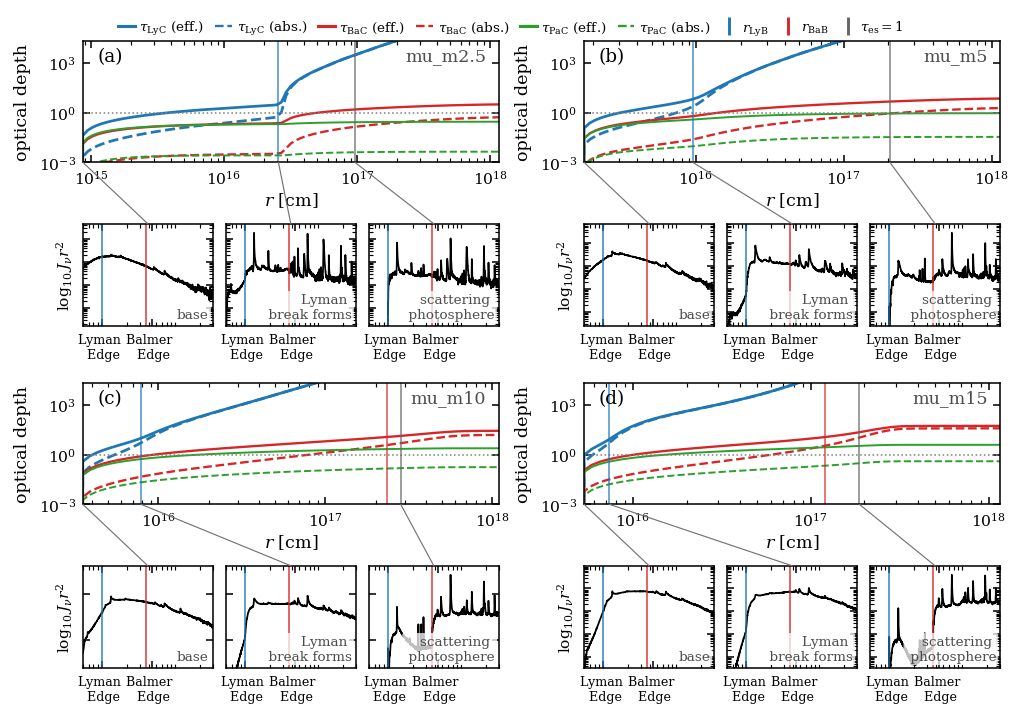

In [2]:
# =====================================================================================
# Two-column figure: all FOUR runs laid out 2x2 (column-major):
#   (a) m2.5 top-left, (b) m10 bottom-left, (c) m5 top-right, (d) m15 bottom-right.
#   Each block = main cumulative LyC/BaC/PaC optical-depth panel + its 3 J_nu r^2 insets
#   at base / Lyman-break radius / scattering photosphere.  Break radii = first r where the
#   J_nu red/blue jump across the edge exceeds a FACTOR OF 5.
# =====================================================================================
from matplotlib.patches import ConnectionPatch
from matplotlib.lines import Line2D

C_PHOT     = '0.4'
ANG_PER_HZ = 2.998e18
LAM_LY_UM  = ANG_PER_HZ / NU_LYMAN  / 1e4   # 0.0912 micron (Lyman edge)
LAM_BA_UM  = ANG_PER_HZ / NU_BALMER / 1e4   # 0.3646 micron (Balmer edge)
BREAK_JUMP = 5.0

fig   = plt.figure(figsize=(7.2, 5.3))
# column-major placement: k -> (row = k%2, col = k//2) gives (a,b) in col 0 and (c,d) in col 1
outer = fig.add_gridspec(2, 2, hspace=0.20, wspace=0.205, left=0.075, right=0.985, top=0.945, bottom=0.10)
letters = iter('acbd')
RUNS_2COL = [RUNS[0], RUNS[2], RUNS[1], RUNS[3]]   # swap m5 <-> m10 panel positions

# one shared one-row legend across the top; break/photosphere keys drawn as VERTICAL bars
vbar = lambda c: Line2D([], [], color=c, marker='|', linestyle='None', markersize=9, markeredgewidth=1.5)
fig.legend([Line2D([], [], color=C_LY, lw=1.6), Line2D([], [], color=C_LY, lw=1.2, ls='--'),
            Line2D([], [], color=C_BA, lw=1.6), Line2D([], [], color=C_BA, lw=1.2, ls='--'),
            Line2D([], [], color=C_PA, lw=1.6), Line2D([], [], color=C_PA, lw=1.2, ls='--'),
            vbar(C_LY), vbar(C_BA), vbar(C_PHOT)],
           [r'$\tau_{\rm LyC}$ (eff.)', r'$\tau_{\rm LyC}$ (abs.)', r'$\tau_{\rm BaC}$ (eff.)',
            r'$\tau_{\rm BaC}$ (abs.)', r'$\tau_{\rm PaC}$ (eff.)', r'$\tau_{\rm PaC}$ (abs.)',
            r'$r_{\rm LyB}$', r'$r_{\rm BaB}$', r'$\tau_{\rm es}=1$'],
           ncol=9, loc='upper center', bbox_to_anchor=(0.5, 0.992), frameon=False, fontsize=7,
           handlelength=1.2, handletextpad=0.35, columnspacing=0.8)

for k, (lab, key) in enumerate(RUNS_2COL):
    row, col = k % 2, k // 2
    rd = run_path(key)
    r, conv, T = optical_depths(rd)
    tes        = tau_es_cum(rd)
    freq, jnu  = load_jnu(rd); n = min(len(r), jnu.shape[1])
    rLy = edge_break_radius(freq, jnu[:, :n], r, NU_LYMAN,  jt=BREAK_JUMP)
    rBa = edge_break_radius(freq, jnu[:, :n], r, NU_BALMER, jt=BREAK_JUMP)

    # converged inner wind only (never integrate tau into the unconverged outer wind)
    cc   = np.where(conv == 0)[0]
    rmax = r[cc[cc < np.searchsorted(r, 1.2e18)][-1]] if len(cc) else r[-1]
    msk  = r <= rmax
    rPh  = photosphere_radius(r, tes, rmax)
    fin    = np.where(T['te1'][msk] > 0)[0]
    rstart = r[msk][fin[0]] if len(fin) else r[0]

    # shorter main panel (0.78); larger subgrid hspace pushes the insets DOWN so the r[cm] label shows
    sub    = outer[row, col].subgridspec(2, 3, height_ratios=[0.78, 0.66], hspace=0.55, wspace=0.10)
    axM    = fig.add_subplot(sub[0, :])
    strips = [fig.add_subplot(sub[1, j]) for j in range(3)]

    # ---- main panel: cumulative optical depth ----
    axM.loglog(r[msk], T['te1'][msk], color=C_LY, lw=1.4)
    axM.loglog(r[msk], T['ta1'][msk], color=C_LY, lw=1.4, ls='--')
    axM.loglog(r[msk], T['te2'][msk], color=C_BA, lw=1.2)
    axM.loglog(r[msk], T['ta2'][msk], color=C_BA, lw=1.2, ls='--')
    axM.loglog(r[msk], T['te3'][msk], color=C_PA, lw=1.0)
    axM.loglog(r[msk], T['ta3'][msk], color=C_PA, lw=1.0, ls='--')
    axM.axhline(1.0, color='0.5', ls=':', lw=0.8)
    if np.isfinite(rLy): axM.axvline(rLy, color=C_LY,   lw=0.8, alpha=0.8)
    if np.isfinite(rBa): axM.axvline(rBa, color=C_BA,   lw=0.8, alpha=0.8)
    if np.isfinite(rPh): axM.axvline(rPh, color=C_PHOT, lw=0.8, alpha=0.8)
    axM.set_xlim(rstart, rmax); axM.set_ylim(1e-3, 2e4)
    axM.set_ylabel('optical depth', fontsize=9)
    axM.set_xlabel(r'$r$ [cm]', fontsize=9, labelpad=2)
    axM.tick_params(which='both', labelsize=8)
    axM.text(0.97, 0.95, f'mu_m{lab}', transform=axM.transAxes,
             ha='right', va='top', fontsize=9, color='0.30')
    axM.text(0.035, 0.95, f'({next(letters)})', transform=axM.transAxes,
             ha='left', va='top', fontsize=9.5)

    # ---- three insets: local J_nu r^2 at base / Lyman break / photosphere ----
    lam_um = ANG_PER_HZ / freq / 1e4
    sl     = (lam_um > 0.05) & (lam_um < 3.0)
    o      = np.argsort(lam_um[sl]); xx = lam_um[sl][o]
    shells = [('base', rstart), ('Lyman \n break forms', rLy), ('scattering \n photosphere', rPh)]
    ys     = []
    for _, rv in shells:
        if not np.isfinite(rv):
            ys.append(None); continue
        idx = int(np.argmin(np.abs(r - rv)))
        ys.append((jnu[sl, idx] * r[idx] ** 2)[o])
    pos = np.concatenate([y[y > 0] for y in ys if y is not None]) if any(y is not None for y in ys) else np.array([1.0])
    yhi = pos.max() * 2.5; ylo = yhi / 3e4

    lblbox = dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.75)
    for j, ((name, rv), strip, y) in enumerate(zip(shells, strips, ys)):
        if y is not None:
            strip.loglog(xx, np.where(y > 0, y, np.nan), color='k', lw=0.9)
        strip.axvline(LAM_LY_UM, color=C_LY, lw=0.9, alpha=0.8)
        strip.axvline(LAM_BA_UM, color=C_BA, lw=0.9, alpha=0.8)
        strip.set_xlim(0.05, 3.0); strip.set_ylim(ylo, yhi)
        strip.set_xticks([LAM_LY_UM, LAM_BA_UM*1.2]); strip.set_xticklabels(['Lyman \n Edge', 'Balmer \n Edge'], fontsize=6)
        strip.tick_params(which='major', labelbottom=True, labelleft=False, labelsize=6.5)
        strip.tick_params(which='minor', labelbottom=False, labelleft=False)
        strip.text(0.97, 0.05, name, transform=strip.transAxes, ha='right', va='bottom', fontsize=7,
                   color='0.3', bbox=lblbox)
        if j == 0: strip.set_ylabel(r'$\log_{10} J_\nu r^2$', fontsize=8)
        if np.isfinite(rv):
            con = ConnectionPatch(xyA=(rv, 0.0), coordsA=axM.get_xaxis_transform(),
                                  xyB=(0.5, 1.0), coordsB=strip.transAxes, color='0.45', lw=0.6)
            con.set_in_layout(False); fig.add_artist(con)

fig.savefig(os.path.join(FIG_DIR, 'FigOpticalDepth.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'FigOpticalDepth.png'), dpi=300)
plt.show()